In [79]:
import numpy as np
import sklearn as sk
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error


import matplotlib.pyplot as plt

from utils import gen_data, show_first_five

In [80]:
x, y = gen_data()

print(x.shape, y.shape)

print(x[:5], '\n', y[:5])

(100, 1) (100,)
[[-6.        ]
 [-5.87878788]
 [-5.75757576]
 [-5.63636364]
 [-5.51515152]] 
 [ 0.15476745 -0.0987637   0.0498698  -0.38759842  0.04263387]


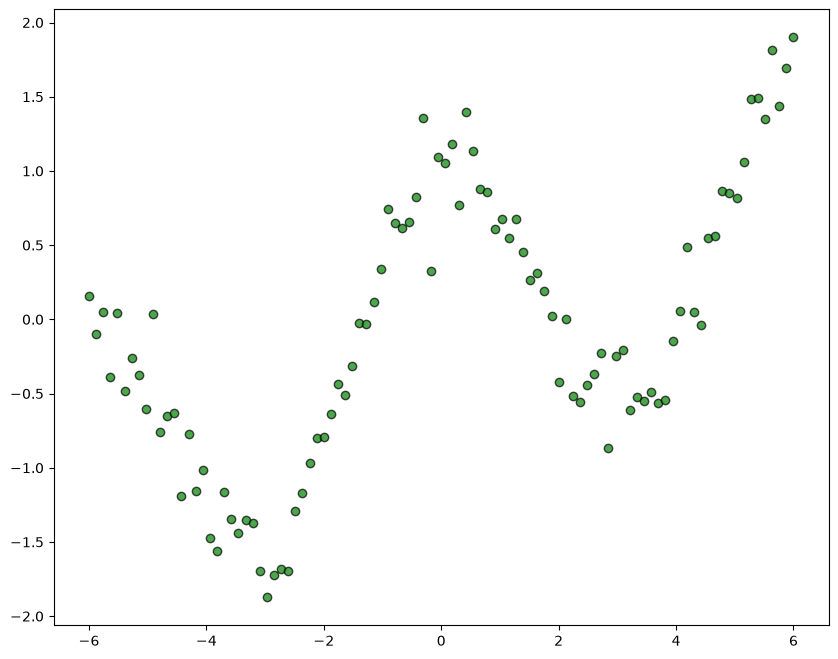

In [81]:
plt.figure(figsize=(10, 8))

plt.scatter(x, y, color='green', alpha=0.7, edgecolors='black')

## Spliting Data

In [82]:
x_train, _x, y_train, _y = train_test_split(x, y, test_size=0.6, random_state=True)
x_cv, x_test, y_cv, y_test = train_test_split(_x, _y, test_size=0.5, random_state=True)

print(x_train.shape, x_cv.shape, x_test.shape)

(40, 1) (30, 1) (30, 1)


## Scaling Data

In [83]:
scaler = StandardScaler()

# Scaling Train Data
x_train_scaled = scaler.fit_transform(x_train)

# Scaling CV Data
x_cv_scaled = scaler.transform(x_cv)

# Scaling Test Data
x_test_scaled = scaler.transform(x_test)

arrays = [x_train_scaled, x_cv_scaled, x_test_scaled]

print(x_train_scaled.shape, x_cv_scaled.shape, x_test_scaled.shape)
show_first_five([x_train_scaled, x_cv_scaled, x_test_scaled])

(40, 1) (30, 1) (30, 1)
[[-0.41812555]
 [ 0.80565654]
 [ 0.94163233]
 [-0.01019818]
 [ 0.15977155]]
[[1.8594689 ]
 [0.43172313]
 [0.83965049]
 [1.55352337]
 [0.66968075]]
[[-0.28214976]
 [ 0.36373523]
 [-0.31614371]
 [-0.55410133]
 [ 0.02379576]]


## Making Data Polynomial

In [ ]:
#TODO: train all on cv and train and then check the lowest MSE on both.

model_mses = []
model_degree = []

for i in range(10):
    
    poly = PolynomialFeatures(degree=2)

    # Making Train Data Polynomial
    x_train_scaled_mapped = poly.fit_transform(x_train_scaled)

    # Making CV Data Polynomial
    x_cv_scaled_mapped = poly.fit_transform(x_cv_scaled)

    # Making Test Data Polynomial
    x_test_scaled_mapped = poly.fit_transform(x_test_scaled)

    # ------------- Training Model ----------------------
    model = Ridge(alpha=0.01)
    model.fit(x_train_scaled_mapped, y_train)
    yhat_train = model.predict(x_train_scaled_mapped)

    print(model.score(x_train_scaled_mapped, y_train))

# ------------- Plotting Model ---------------------
plt.figure(figsize=(10,8))

idx = np.argsort(x_train[:, 0])

plt.scatter(x_train, y_train, edgecolors='black', color='green', label='Train')
plt.plot(x_train[idx], yhat_train[idx], label='model')

plt.grid(True)
plt.show()

In [ ]:
# model = Ridge(alpha=0.01)
# model.fit(x_train_scaled_mapped, y_train)
# yhat_train = model.predict(x_train_scaled_mapped)

# print(model.score(x_train_scaled_mapped, y_train))

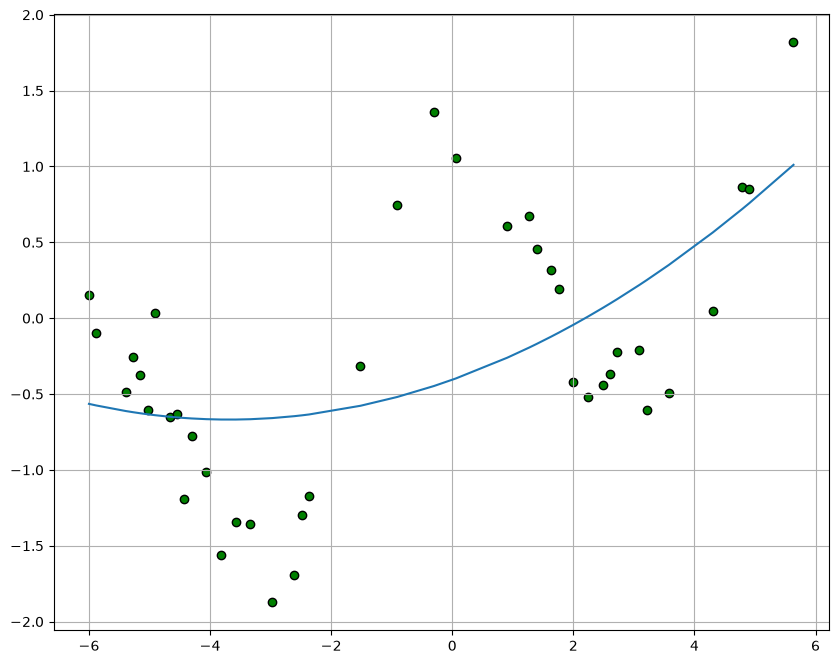

In [ ]:
# plt.figure(figsize=(10,8))

# idx = np.argsort(x_train[:, 0])

# plt.scatter(x_train, y_train, edgecolors='black', color='green', label='Train')
# plt.plot(x_train[idx], yhat_train[idx], label='model')

# plt.grid(True)
# plt.show()